# Tubes 1 IF3270 Pembelajaran Mesin

**Nama Anggota:**
- 13523137 — Muhammad Aulia Azka
- 13523147 — Frederiko Eldad Mugiyono
- 13523149 — Naufarrel Zhafif Abhista

**Kelas:** K3

---

In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 0. Import Libraries & Load Data

In [2]:
%pip install -r ../../requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import sys
from pathlib import Path

SRC_ROOT = Path.cwd().parent

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

print("Current working directory:", Path.cwd())
print("Added to sys.path:", SRC_ROOT)

Current working directory: d:\CompSCI_ITB\Materi\Semester_6\ML\Tubes\Tubes1\ML-FFNN\src\notebook
Added to sys.path: d:\CompSCI_ITB\Materi\Semester_6\ML\Tubes\Tubes1\ML-FFNN\src


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from pathlib import Path
from sklearn.base import BaseEstimator, TransformerMixin

from ffnn.autodiff.model import ADModel
from ffnn.autodiff.model import Tensor
from ffnn.initializers.Initializer import Xavier, He, Normal
from ffnn.optimizers.Optimizer import Adam, GradientDescent
from ffnn.regularizers.Regularizer import L1, L2

# Evaluation
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, confusion_matrix


import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

In [5]:
csv_path = Path("..") / "data" / "global_student_placement_and_salary.csv"
df = pd.read_csv(csv_path)

df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [6]:
target_col = "placement_status"
stratify_col = df[target_col] if df[target_col].nunique() < 50 else None
train_set, val_set = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=stratify_col
)

print(f"train_set: {train_set.shape}")
print(f"val_set: {val_set.shape}")

train_set: (8000, 12)
val_set: (2000, 12)


---
## 1. Exploratory Data Analysis (EDA)


### 1.1 Gambaran Umum Dataset

In [7]:
train_set.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
2014,7.663580,1,Tier 1,Germany,300+,0,89.685008,75.081917,Data Science,Consulting,6.405241,Placed
3522,6.227468,1,Tier 3,UK,Top 100,2,86.843058,47.547940,Data Science,Tech,3.410235,Placed
83,6.585384,0,Tier 2,USA,300+,1,56.855886,93.923403,Cloud,Consulting,7.129919,Placed
9038,7.619218,0,Tier 2,India,100-300,2,54.140379,46.012573,Cloud,Finance,6.924698,Placed
3984,7.194306,4,Tier 2,India,100-300,0,54.974271,61.241897,AI/ML,Healthcare,5.029638,Not Placed


In [8]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, 2014 to 6802
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      8000 non-null   float64
 1   backlogs                  8000 non-null   int64  
 2   college_tier              8000 non-null   object 
 3   country                   8000 non-null   object 
 4   university_ranking_band   8000 non-null   object 
 5   internship_count          8000 non-null   int64  
 6   aptitude_score            8000 non-null   float64
 7   communication_score       8000 non-null   float64
 8   specialization            8000 non-null   object 
 9   industry                  8000 non-null   object 
 10  internship_quality_score  8000 non-null   float64
 11  placement_status          8000 non-null   object 
dtypes: float64(4), int64(2), object(6)
memory usage: 812.5+ KB


In [9]:
train_set.describe(include='all')

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
count,8000.000000,8000.000000,8000,8000,8000,8000.000000,8000.000000,8000.000000,8000,8000,8000.000000,8000
unique,NaN,NaN,3,5,3,NaN,NaN,NaN,5,6,NaN,2
top,NaN,NaN,Tier 2,Germany,300+,NaN,NaN,NaN,Data Science,Consulting,NaN,Placed
freq,NaN,NaN,3181,1662,3241,NaN,NaN,NaN,1650,1391,NaN,4922
mean,7.000000,1.245750,NaN,NaN,NaN,1.490750,69.777144,65.254494,NaN,NaN,5.027980,NaN
std,0.799038,1.151422,NaN,NaN,NaN,1.196597,14.694668,14.806830,NaN,NaN,1.508694,NaN
min,4.000000,0.000000,NaN,NaN,NaN,0.000000,30.000000,30.000000,NaN,NaN,1.000000,NaN
25%,6.462682,0.000000,NaN,NaN,NaN,1.000000,59.768531,55.166849,NaN,NaN,4.019012,NaN
50%,6.999957,1.000000,NaN,NaN,NaN,1.000000,70.071892,65.102099,NaN,NaN,5.023714,NaN
75%,7.536212,2.000000,NaN,NaN,NaN,2.000000,80.109599,75.462671,NaN,NaN,6.034673,NaN


In [10]:
# Cek missing values
missing = train_set.isnull().sum()
missing_pct = (missing / len(train_set) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct}).query('`Missing Count` > 0')

,Missing Count,Missing (%)


In [11]:
# Distribusi kelas target
print(train_set['placement_status'].value_counts())
print(train_set['placement_status'].value_counts(normalize=True).round(3))

placement_status
Placed        4922
Not Placed    3078
Name: count, dtype: int64
placement_status
Placed        0.615
Not Placed    0.385
Name: proportion, dtype: float64


In [12]:
train_set.value_counts("specialization")

specialization
Data Science     1650
Core CS          1617
Cloud            1584
Cybersecurity    1581
AI/ML            1568
Name: count, dtype: int64

In [13]:
train_set.value_counts("college_tier")

college_tier
Tier 2    3181
Tier 1    2446
Tier 3    2373
Name: count, dtype: int64

### 1.2 Distribusi Target dan Fitur Kategorikal Utama


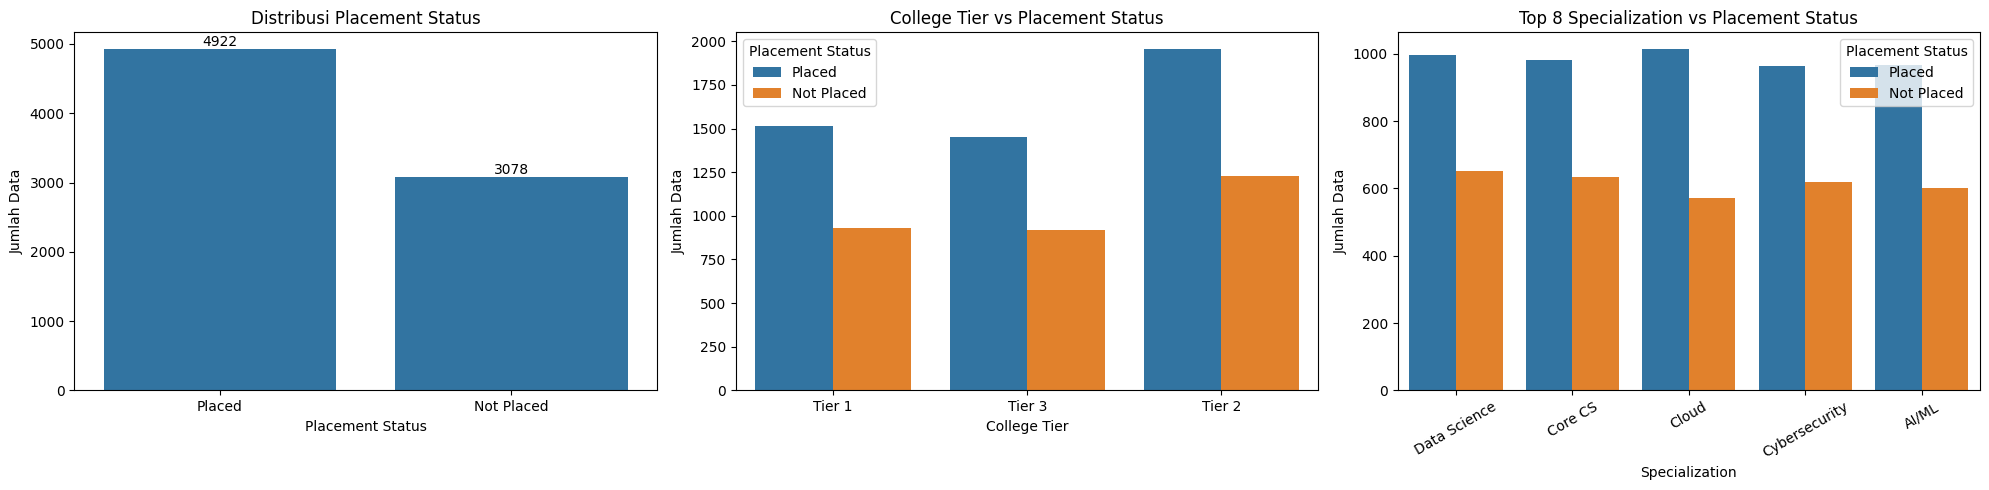

,proporsi
placement_status,
Placed,61.52
Not Placed,38.48


In [14]:
train_df = train_set.copy()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Distribusi target
target_order = train_df[target_col].value_counts().index
sns.countplot(data=train_df, x=target_col, order=target_order, ax=axes[0])
axes[0].set_title("Distribusi Placement Status")
axes[0].set_xlabel("Placement Status")
axes[0].set_ylabel("Jumlah Data")

for p in axes[0].patches:
    axes[0].annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=10
    )

sns.countplot(data=train_df, x="college_tier", hue=target_col, ax=axes[1])
axes[1].set_title("College Tier vs Placement Status")
axes[1].set_xlabel("College Tier")
axes[1].set_ylabel("Jumlah Data")
axes[1].legend(title="Placement Status")

# Top specialization vs target
top_spec = train_df["specialization"].value_counts().head(8).index
spec_df = train_df[train_df["specialization"].isin(top_spec)]

sns.countplot(
    data=spec_df,
    x="specialization",
    hue=target_col,
    order=top_spec,
    ax=axes[2]
)
axes[2].set_title("Top 8 Specialization vs Placement Status")
axes[2].set_xlabel("Specialization")
axes[2].set_ylabel("Jumlah Data")
axes[2].tick_params(axis="x", rotation=30)
axes[2].legend(title="Placement Status")

plt.tight_layout()
plt.show()

# Tabel proporsi target
display(
    train_df[target_col]
    .value_counts(normalize=True)
    .rename("proporsi")
    .mul(100)
    .round(2)
    .to_frame()
)

### 1.3 Korelasi Antar Fitur Numerik


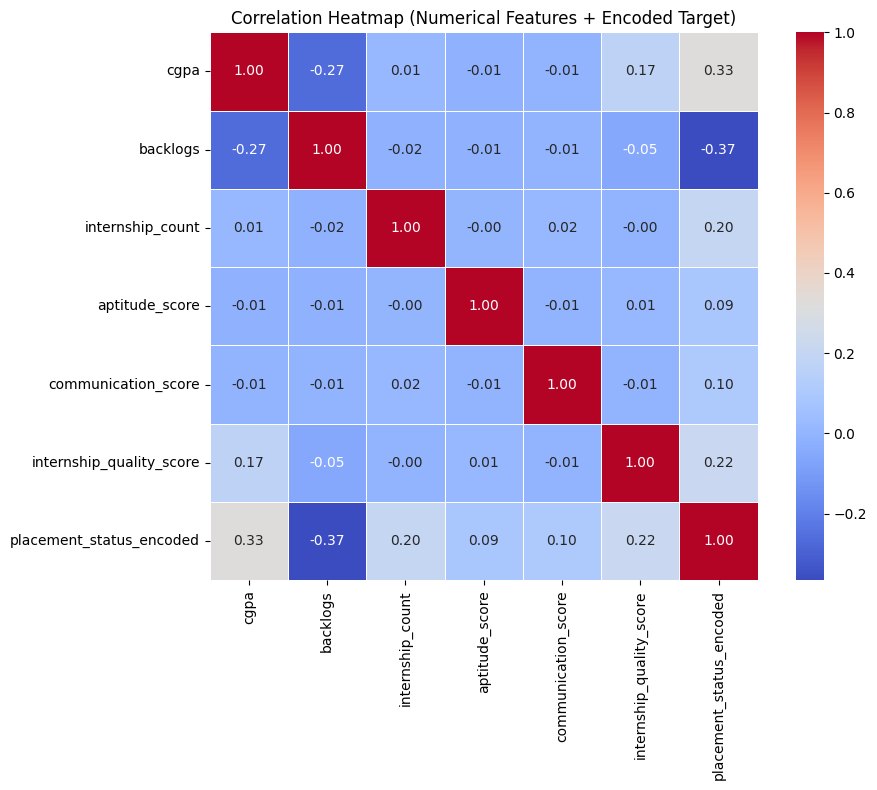

Mapping target untuk korelasi: {'Not Placed': 0, 'Placed': 1}


In [15]:
num_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()

target_mapping = {label: idx for idx, label in enumerate(sorted(train_df[target_col].dropna().unique()))}
corr_df = train_df[num_cols].copy()
corr_df[f"{target_col}_encoded"] = train_df[target_col].map(target_mapping)

plt.figure(figsize=(10, 8))
corr_matrix = corr_df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap (Numerical Features + Encoded Target)")
plt.tight_layout()
plt.show()

print("Mapping target untuk korelasi:", target_mapping)

### 1.4 Sebaran Fitur Numerik dan Outlier terhadap Placement Status


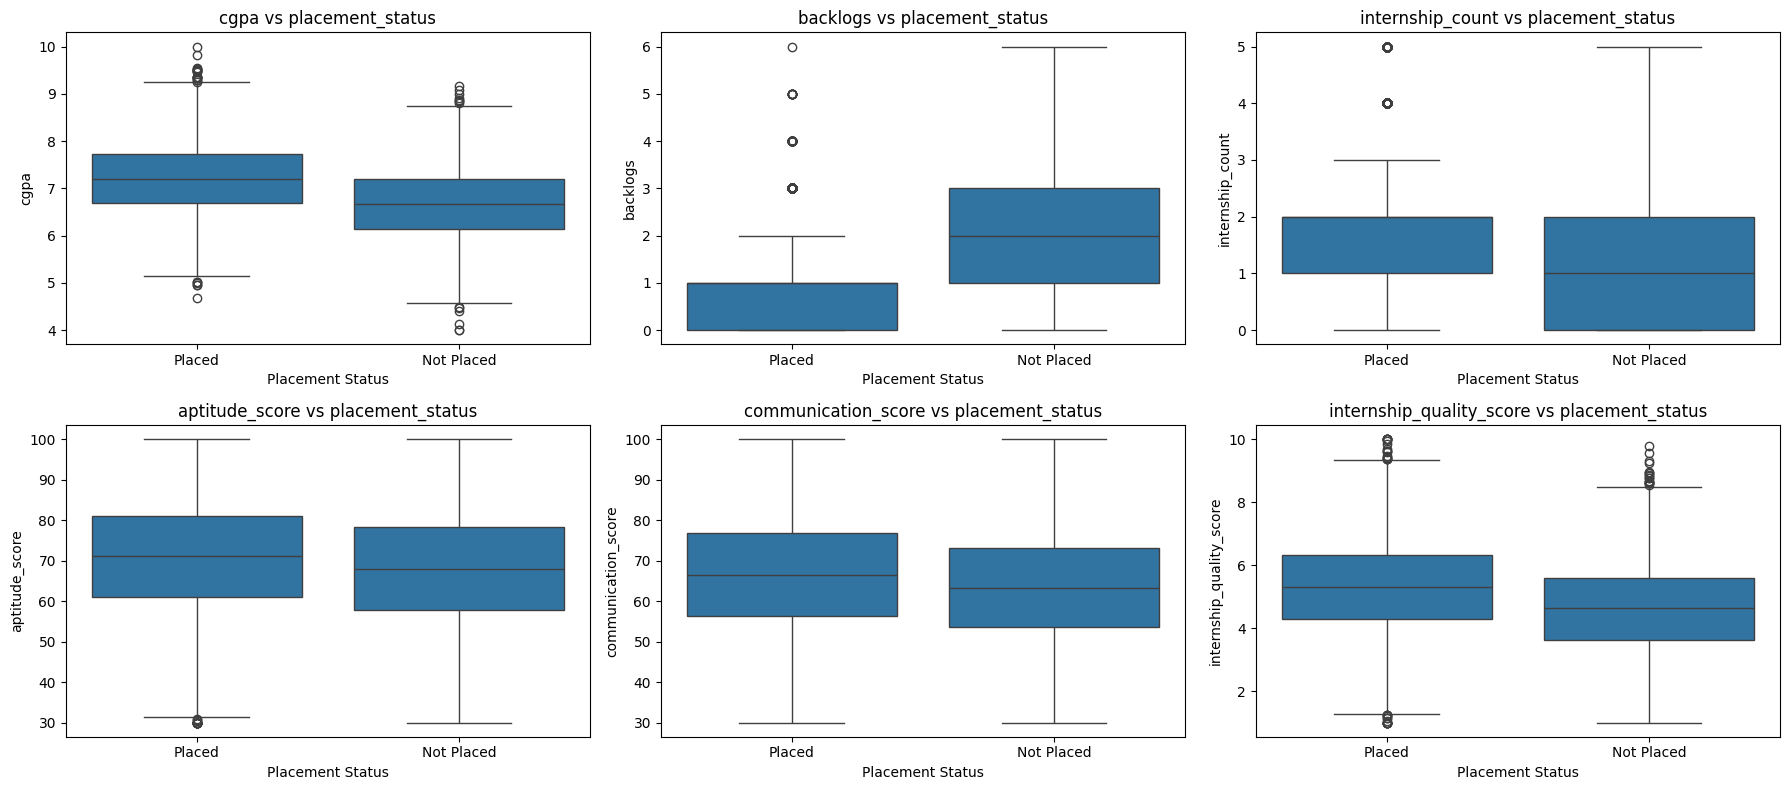

,feature,n_outlier,pct_outlier
2,internship_count,518,6.48
0,cgpa,59,0.74
5,internship_quality_score,31,0.39
1,backlogs,23,0.29
3,aptitude_score,0,0.00
4,communication_score,0,0.00


In [16]:
num_features = train_df.select_dtypes(include=[np.number]).columns.tolist()

n = len(num_features)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, num_features):
    sns.boxplot(data=train_df, x=target_col, y=col, ax=ax)
    ax.set_title(f"{col} vs {target_col}")
    ax.set_xlabel("Placement Status")
    ax.set_ylabel(col)

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Ringkasan outlier berbasis IQR
outlier_rows = []
for col in num_features:
    q1 = train_df[col].quantile(0.25)
    q3 = train_df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((train_df[col] < lower) | (train_df[col] > upper)).sum()
    outlier_rows.append({
        "feature": col,
        "n_outlier": int(n_out),
        "pct_outlier": round(n_out / len(train_df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_rows).sort_values("pct_outlier", ascending=False)
display(outlier_df)

---
## 2. Data Cleaning and Preprocessing


In [17]:
TARGET_COL = "placement_status"

CAT_COLS = [
    "college_tier",
    "country",
    "university_ranking_band",
    "specialization",
    "industry",
]

NUM_COLS = [
    "cgpa",
    "backlogs",
    "internship_count",
    "aptitude_score",
    "communication_score",
    "internship_quality_score",
]

print("Categorical:", CAT_COLS)
print("Numerical:  ", NUM_COLS)

train = train_set.copy()
val = val_set.copy()

Categorical: ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']
Numerical:   ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']


### 2.1 Feature Engineering

### 2.2 Preprocessing


In [18]:
class IQRClipper(BaseEstimator, TransformerMixin):
  def __init__(self, factor=1.5):
    self.factor = factor

  def fit(self, X, y=None):
    X = np.asarray(X, dtype=float)
    q1 = np.nanquantile(X, 0.25, axis=0)
    q3 = np.nanquantile(X, 0.75, axis=0)
    IQR = q3 - q1
    self.lower_ = q1 - IQR * self.factor
    self.upper_ = q3 + IQR * self.factor
    return self

  def transform(self, X):
    X = np.asarray(X, dtype=float)
    return np.clip(X, self.lower_, self.upper_)

# OneHotEncoder
try:
  onehoten = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except:
  onehoten = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clipper", IQRClipper()),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehoten)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUM_COLS),
        ("cat", categorical_transformer, CAT_COLS)
    ],
    remainder="drop"
)


### 2.6 Train-Validation Split

In [19]:
X_train_df = train[NUM_COLS + CAT_COLS]
X_val_df   = val[NUM_COLS + CAT_COLS]

label_map = {"Not Placed": 0, "Placed": 1}
y_train = train[TARGET_COL].map(label_map).to_numpy()
y_val   = val[TARGET_COL].map(label_map).to_numpy()

X_train = preprocessor.fit_transform(X_train_df)
X_val   = preprocessor.transform(X_val_df)

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)

X_train: (8000, 28)
X_val:   (2000, 28)
y_train: (8000,)
y_val:   (2000,)


In [20]:
if hasattr(X_train, "toarray"):
    X_train = X_train.toarray()
if hasattr(X_val, "toarray"):
    X_val = X_val.toarray()
X_train = np.asarray(X_train, dtype=np.float64)
X_val   = np.asarray(X_val, dtype=np.float64)
y_train = np.asarray(y_train, dtype=np.float64).reshape(-1, 1)
y_val   = np.asarray(y_val, dtype=np.float64).reshape(-1, 1)

print("X_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape  :", y_val.shape)

print("X_train dtype:", X_train.dtype)
print("X_val dtype  :", X_val.dtype)

print("NaN X_train:", np.isnan(X_train).any())
print("NaN X_val  :", np.isnan(X_val).any())

print("Unique y_train:", np.unique(y_train))
print("Unique y_val  :", np.unique(y_val))

X_train shape: (8000, 28)
X_val shape  : (2000, 28)
y_train shape: (8000, 1)
y_val shape  : (2000, 1)
X_train dtype: float64
X_val dtype  : float64
NaN X_train: False
NaN X_val  : False
Unique y_train: [0. 1.]
Unique y_val  : [0. 1.]


---
## 3. Baseline Config


In [21]:
np.random.seed(RANDOM_STATE)

input_dim = X_train.shape[1]

baseline_config = {
    "layer_sizes": [input_dim, 32, 16, 1],
    "activations": ["relu", "relu", "sigmoid"],
    "loss": "bce",
    "optimizer": Adam(learning_rate=0.001),
    "initializer": Xavier(gain=1.0),
    "regularizer": None,
    "epochs": 10,
    "batch_size": 32,
    "learning_rate": 0.001,
    "verbose": 1,
}

baseline_model = ADModel(
    layer_sizes=baseline_config["layer_sizes"],
    activations=baseline_config["activations"],
    loss=baseline_config["loss"],
    optimizer=baseline_config["optimizer"],
    initializer=baseline_config["initializer"],
    regularizer=baseline_config["regularizer"],
)

baseline_history = baseline_model.fit(
    X_train, y_train,
    X_val, y_val,
    epochs=baseline_config["epochs"],
    batch_size=baseline_config["batch_size"],
    verbose=baseline_config["verbose"],
    learning_rate=baseline_config["learning_rate"],
)

Training: 100%|██████████| 10/10 [00:00<00:00, 13.02it/s, train_loss=0.4729, val_loss=0.5149]


In [22]:
y_val_prob = baseline_model.predict(X_val)
y_val_pred = (y_val_prob >= 0.5).astype(int)

print("Accuracy :", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred, zero_division=0))
print("Recall   :", recall_score(y_val, y_val_pred, zero_division=0))
print("F1-score :", f1_score(y_val, y_val_pred, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_val, y_val_pred))

Accuracy : 0.7515
Precision: 0.7663280116110305
Recall   : 0.8578391551584078
F1-score : 0.8095055576849367
Confusion matrix:
 [[ 447  322]
 [ 175 1056]]


In [23]:
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

print("Unique y_train:", np.unique(y_train))
print("Unique y_val:", np.unique(y_val))

print("Pred prob min :", y_val_prob.min())
print("Pred prob max :", y_val_prob.max())
print("Pred prob mean:", y_val_prob.mean())

print("First 20 probs:", y_val_prob[:20].reshape(-1))
print("Predicted positives:", y_val_pred.sum(), "out of", len(y_val_pred))

y_train shape: (8000, 1)
y_val shape: (2000, 1)
Unique y_train: [0. 1.]
Unique y_val: [0. 1.]
Pred prob min : 0.005888537035806577
Pred prob max : 0.9960220666519417
Pred prob mean: 0.6429625044658294
First 20 probs: [0.44726981 0.39649991 0.69126542 0.53104794 0.98602856 0.72080258
 0.56539141 0.3947208  0.58823181 0.81189991 0.1826344  0.95900344
 0.22427193 0.06508709 0.52642311 0.46377705 0.6858248  0.86281938
 0.70643472 0.17615758]
Predicted positives: 1378 out of 2000


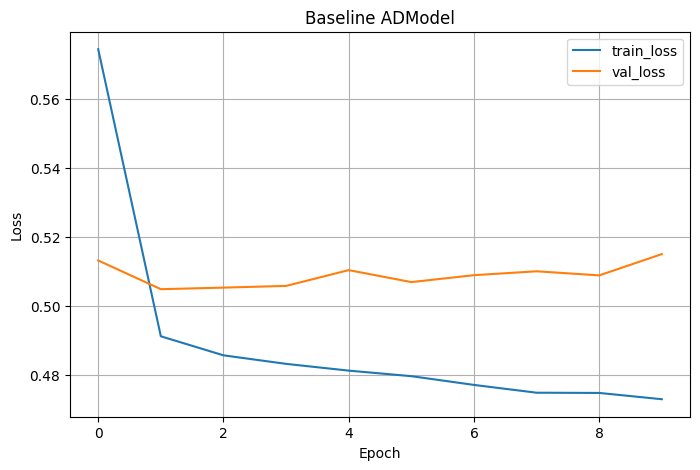

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(baseline_history["train_loss"], label="train_loss")
plt.plot(baseline_history["val_loss"], label="val_loss")
plt.title("Baseline ADModel")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
# # Pipeline
# def make_pipe(model):
#   return Pipeline(steps=[
#       ("preprocessor", preprocessor),
#       ("model", model)
#   ])

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# def tune_model(pipe, param_grid=None, param_distributions=None, n_iter=5, scoring="f1_macro"):
#   if param_distributions is not None:
#     search = RandomizedSearchCV(
#         pipe,
#         param_distributions=param_distributions,
#         n_iter=n_iter,
#         scoring=scoring,
#         cv=cv,
#         n_jobs=-1,
#         random_state=RANDOM_STATE,
#         verbose=1
#     )
#   else:
#     search = GridSearchCV(
#         pipe,
#         param_grid=param_grid,
#         scoring=scoring,
#         cv=cv,
#         n_jobs=-1,
#         verbose=1
#     )

#   search.fit(X_train, y_train)
#   return search

# trained_models = {}
# results = {}

# 4. Eksperimen

In [26]:
def run_ad_experiment(name, layer_sizes, activations,
                      optimizer, initializer, regularizer=None,
                      epochs=10, batch_size=32, learning_rate=0.001, verbose=0):
    
    model = ADModel(
        layer_sizes=layer_sizes,
        activations=activations,
        loss="bce",
        optimizer=optimizer,
        initializer=initializer,
        regularizer=regularizer,
    )
    
    history = model.fit(
        X_train, y_train,
        X_val, y_val,
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose,
        learning_rate=learning_rate,
    )
    
    y_val_prob = model.predict(X_val)
    y_val_pred = (y_val_prob >= 0.5).astype(int)

    return {
        "name": name,
        "layer_sizes": layer_sizes,
        "history": history,
        "model": model,
        "accuracy": accuracy_score(y_val, y_val_pred),
        "precision": precision_score(y_val, y_val_pred, zero_division=0),
        "recall": recall_score(y_val, y_val_pred, zero_division=0),
        "f1": f1_score(y_val, y_val_pred, zero_division=0),
        "conf_matrix": confusion_matrix(y_val, y_val_pred)
    }


def summarize_results(results):
    return pd.DataFrame([
        {
            "model": r["name"],
            "layer_sizes": str(r["layer_sizes"]),
            "accuracy": r["accuracy"],
            "precision": r["precision"],
            "recall": r["recall"],
            "f1": r["f1"],
            "final_train_loss": r["history"]["train_loss"][-1],
            "final_val_loss": r["history"]["val_loss"][-1],
        }
        for r in results
    ]).sort_values("f1", ascending=False)


def plot_train_loss_comparison(results, title="Training Loss Comparison"):
    plt.figure(figsize=(8, 5))
    for r in results:
        plt.plot(r["history"]["train_loss"], label=f"{r['name']} train")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_val_loss_comparison(results, title="Validation Loss Comparison"):
    plt.figure(figsize=(8, 5))
    for r in results:
        plt.plot(r["history"]["val_loss"], label=f"{r['name']} val")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

## 4.1 Variasi Depth dan Width

### 4.1.1 Width 

In [27]:
# TODO: Variasi 1
width_configs = {
    "width_small": [input_dim, 16, 8, 1],
    "width_base":  [input_dim, 32, 16, 1],
    "width_large": [input_dim, 64, 32, 1],
}

width_results = []

for name, layers in width_configs.items():
    result = run_ad_experiment(
        name=name,
        layer_sizes=layers,
        activations=["relu", "relu", "sigmoid"],
        optimizer=Adam(learning_rate=0.001),
        initializer=Xavier(gain=1.0),
        regularizer=None,
        epochs=10,
        batch_size=32,
        learning_rate=0.001,
        verbose=1
    )
    width_results.append(result)

width_df = summarize_results(width_results)
width_df

Training: 100%|██████████| 10/10 [00:00<00:00, 12.58it/s, train_loss=0.4644, val_loss=0.5091]


,model,layer_sizes,accuracy,precision,recall,f1,final_train_loss,final_val_loss
0,width_small,"[28, 16, 8, 1]",0.7530,0.771155,0.851340,0.809266,0.482082,0.505616
2,width_large,"[28, 64, 32, 1]",0.7455,0.773485,0.829407,0.800470,0.464423,0.509128
1,width_base,"[28, 32, 16, 1]",0.7455,0.785150,0.807474,0.796155,0.473561,0.512406


### 4.1.2 Depth

In [28]:
depth_configs = {
    "depth_1_hidden": [input_dim, 32, 1],
    "depth_2_hidden": [input_dim, 32, 32, 1],
    "depth_3_hidden": [input_dim, 32, 32, 32, 1],
}

depth_results = []

for name, layers in depth_configs.items():
    activations = ["relu"] * (len(layers) - 2) + ["sigmoid"]
    
    result = run_ad_experiment(
        name=name,
        layer_sizes=layers,
        activations=activations,
        optimizer=Adam(learning_rate=0.001),
        initializer=Xavier(gain=1.0),
        regularizer=None,
        epochs=10,
        batch_size=32,
        learning_rate=0.001,
        verbose=1
    )
    depth_results.append(result)

depth_df = summarize_results(depth_results)
depth_df

Training: 100%|██████████| 10/10 [00:00<00:00, 10.99it/s, train_loss=0.4645, val_loss=0.5163]


,model,layer_sizes,accuracy,precision,recall,f1,final_train_loss,final_val_loss
0,depth_1_hidden,"[28, 32, 1]",0.7555,0.781061,0.837530,0.808310,0.478745,0.506276
2,depth_3_hidden,"[28, 32, 32, 32, 1]",0.7450,0.754770,0.867587,0.807256,0.464494,0.516259
1,depth_2_hidden,"[28, 32, 32, 1]",0.7465,0.772180,0.834281,0.802030,0.468470,0.516054


### Plot

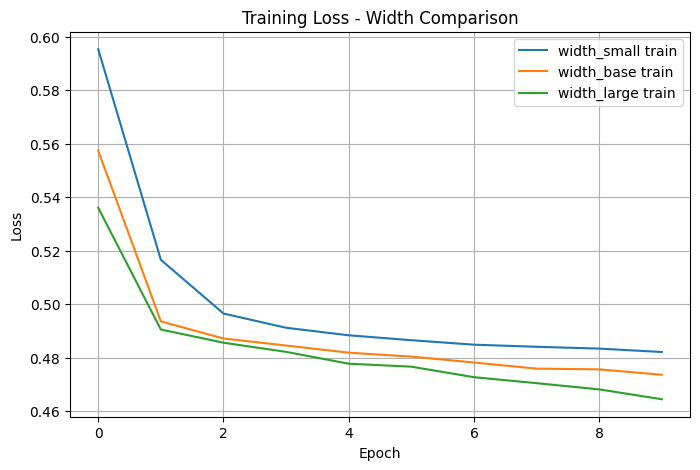

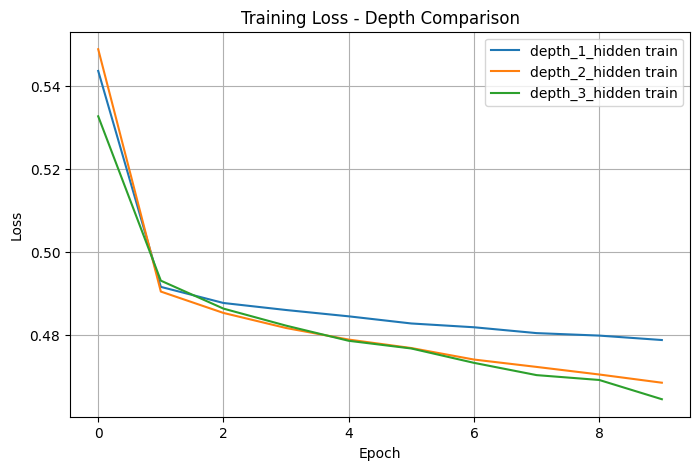

In [29]:
plot_train_loss_comparison(width_results, "Training Loss - Width Comparison")
plot_train_loss_comparison(depth_results, "Training Loss - Depth Comparison")

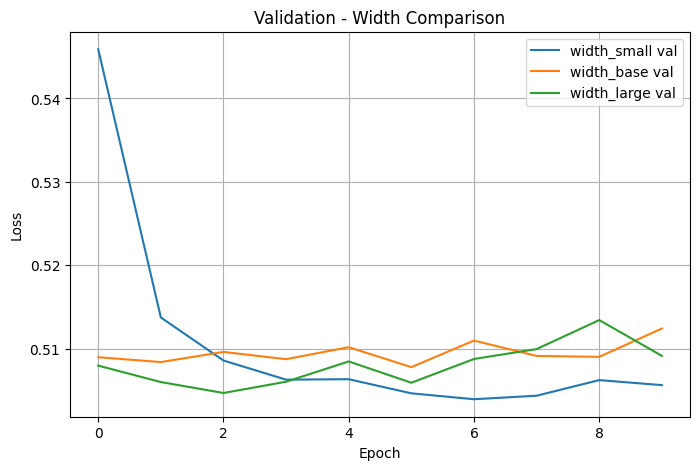

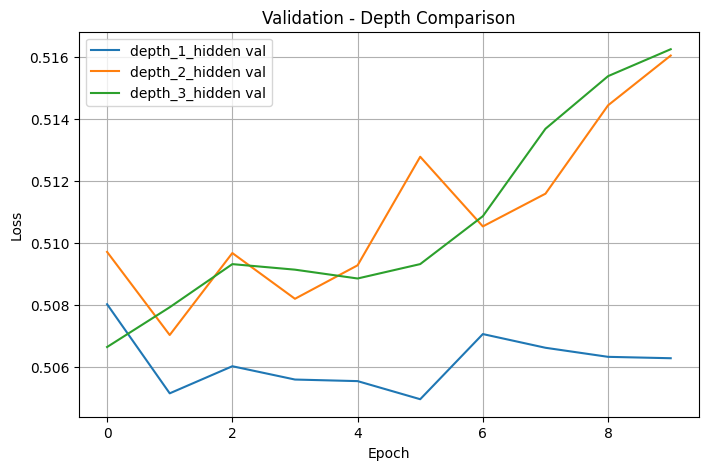

In [30]:
plot_val_loss_comparison(width_results, "Validation - Width Comparison")
plot_val_loss_comparison(depth_results, "Validation - Depth Comparison")

In [31]:
best_width = width_df.iloc[0]
best_depth = depth_df.iloc[0]

print("Best width config:")
print(best_width)

print("\nBest depth config:")
print(best_depth)

Best width config:
model                  width_small
layer_sizes         [28, 16, 8, 1]
accuracy                     0.753
precision                 0.771155
recall                     0.85134
f1                        0.809266
final_train_loss          0.482082
final_val_loss            0.505616
Name: 0, dtype: object

Best depth config:
model               depth_1_hidden
layer_sizes            [28, 32, 1]
accuracy                    0.7555
precision                 0.781061
recall                     0.83753
f1                         0.80831
final_train_loss          0.478745
final_val_loss            0.506276
Name: 0, dtype: object


## 4.2 Variasi Fungsi Aktivasi 

### 4.2.1 Helper

In [32]:
activation_configs = {
    "linear":  ["linear", "relu", "sigmoid"],
    "relu":    ["relu", "relu", "sigmoid"],
    "sigmoid": ["sigmoid", "relu", "sigmoid"],
    "tanh":    ["tanh", "relu", "sigmoid"],
}

activation_results = []

for name, activations in activation_configs.items():
    result = run_ad_experiment(
        name=f"act_{name}",
        layer_sizes=[input_dim, 32, 16, 1],
        activations=activations,
        optimizer=Adam(learning_rate=0.001),
        initializer=Xavier(gain=1.0),
        regularizer=None,
        epochs=10,
        batch_size=32,
        learning_rate=0.001,
        verbose=1
    )
    activation_results.append(result)

activation_df = summarize_results(activation_results)
activation_df

Training: 100%|██████████| 10/10 [00:00<00:00, 14.04it/s, train_loss=0.4806, val_loss=0.5052]


,model,layer_sizes,accuracy,precision,recall,f1,final_train_loss,final_val_loss
0,act_linear,"[28, 32, 16, 1]",0.7590,0.779686,0.848091,0.812451,0.481894,0.504920
3,act_tanh,"[28, 32, 16, 1]",0.7550,0.772226,0.853777,0.810957,0.480571,0.505196
2,act_sigmoid,"[28, 32, 16, 1]",0.7545,0.779456,0.838343,0.807828,0.487330,0.501568
1,act_relu,"[28, 32, 16, 1]",0.7520,0.773234,0.844842,0.807453,0.475742,0.510515


### 4.2.2 Grafik Training loss dan Validation loss

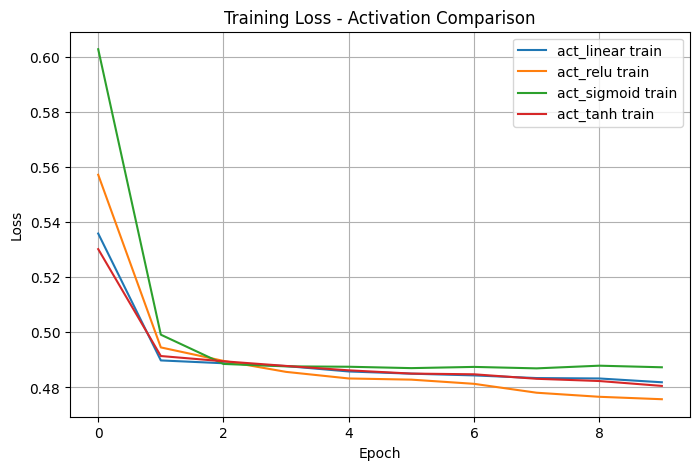

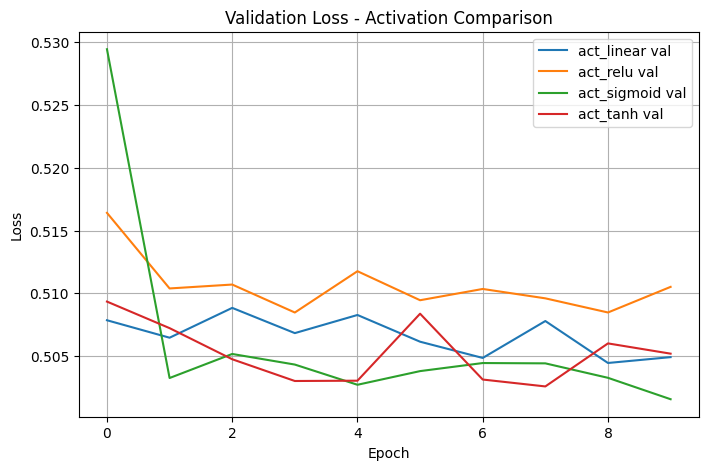

In [33]:
plot_train_loss_comparison(activation_results, "Training Loss - Activation Comparison")
plot_val_loss_comparison(activation_results, "Validation Loss - Activation Comparison")

### 4.2.3 Plot Distribusi Bobot dan Gradien

In [34]:
def compute_ad_gradients_once(model, X_sample, y_sample):
    x_t = Tensor.from_numpy(X_sample)
    y_t = Tensor.from_numpy(y_sample)

    pred = model.network.forward(x_t)
    loss_t = model._loss_fn(pred, y_t)
    loss_t.backward()

    return float(loss_t.data)

In [35]:
# X_sample = X_train[:128]
# y_sample = y_train[:128]




Weight distribution for act_linear


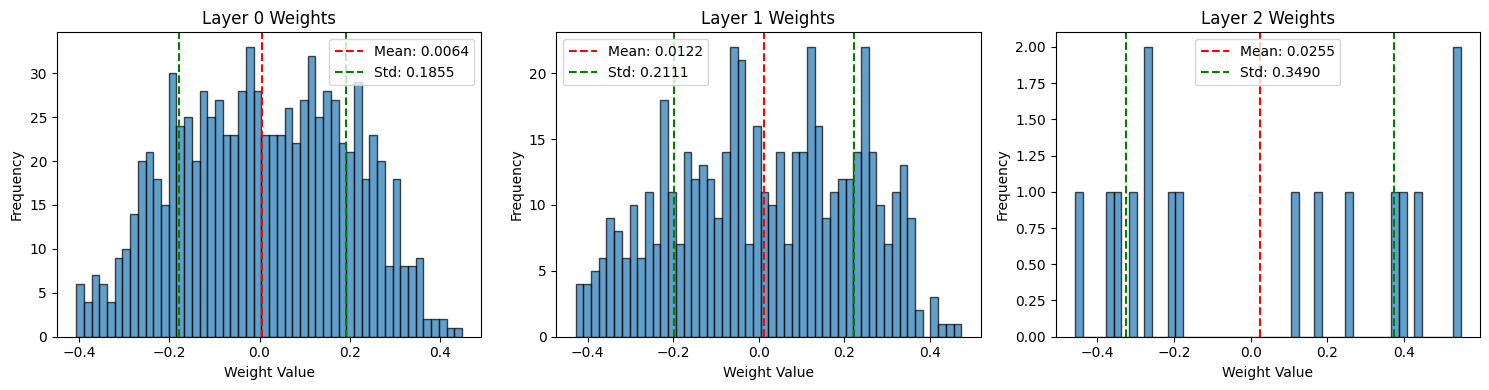


Weight distribution for act_relu


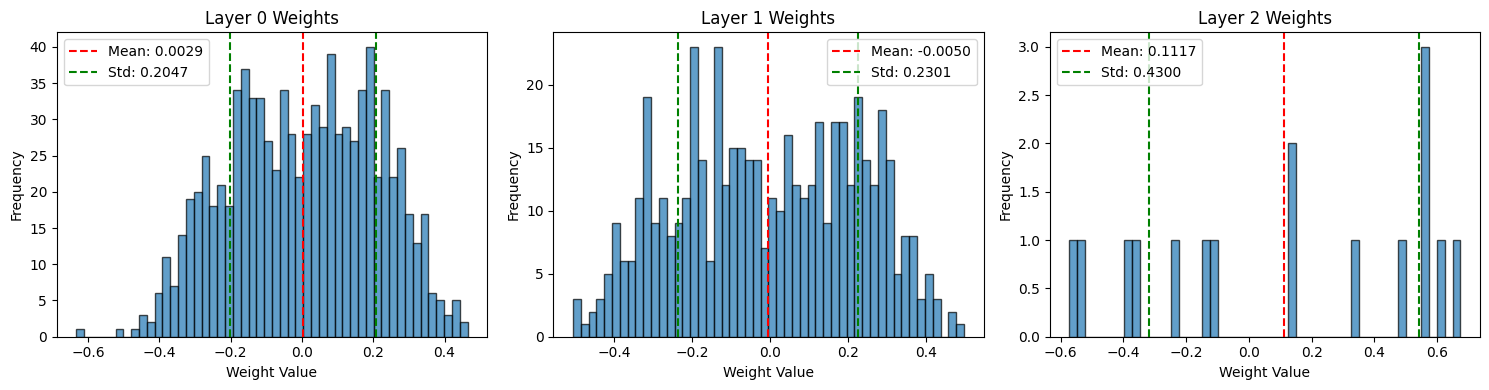


Weight distribution for act_sigmoid


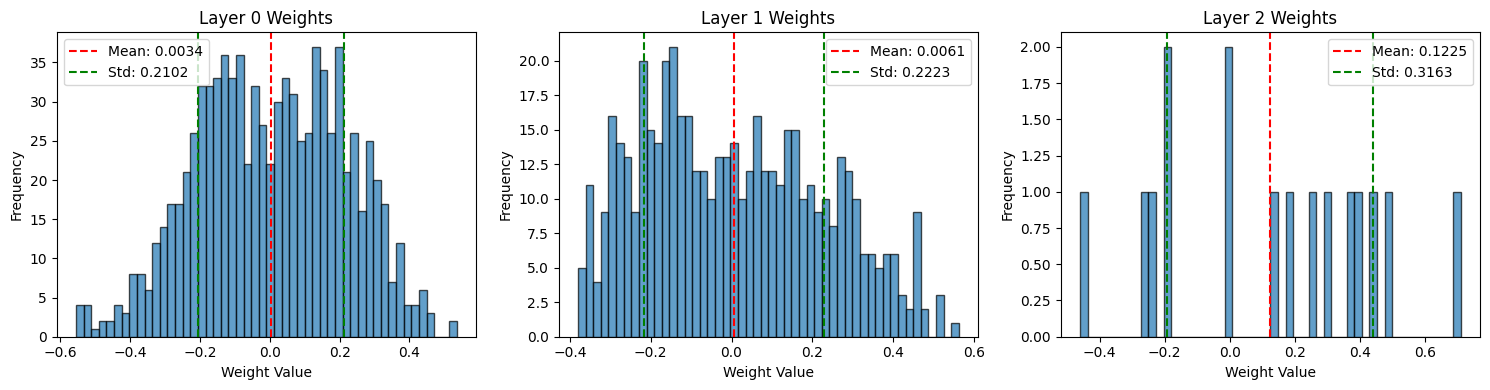


Weight distribution for act_tanh


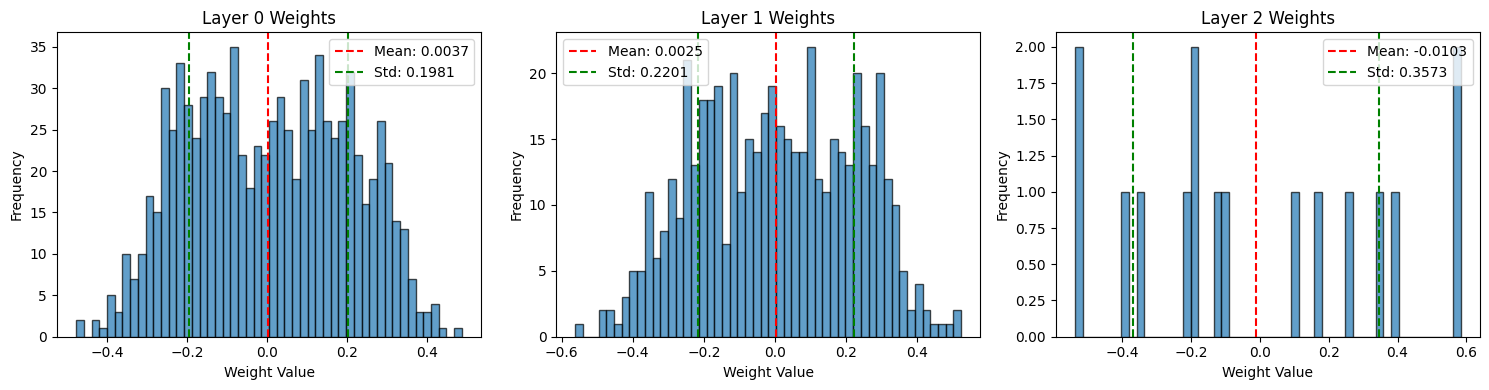


Gradient distribution for act_linear


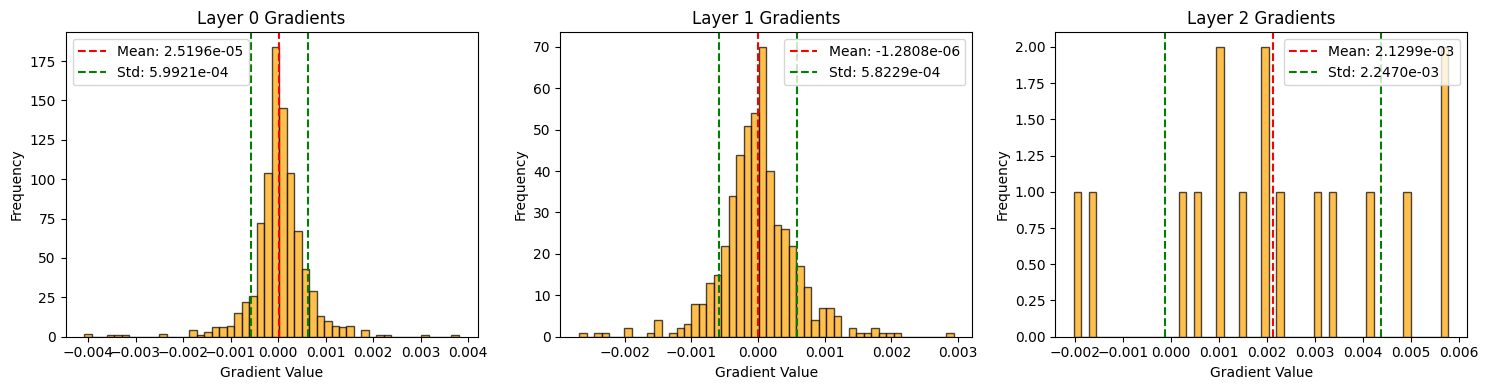


Gradient distribution for act_relu


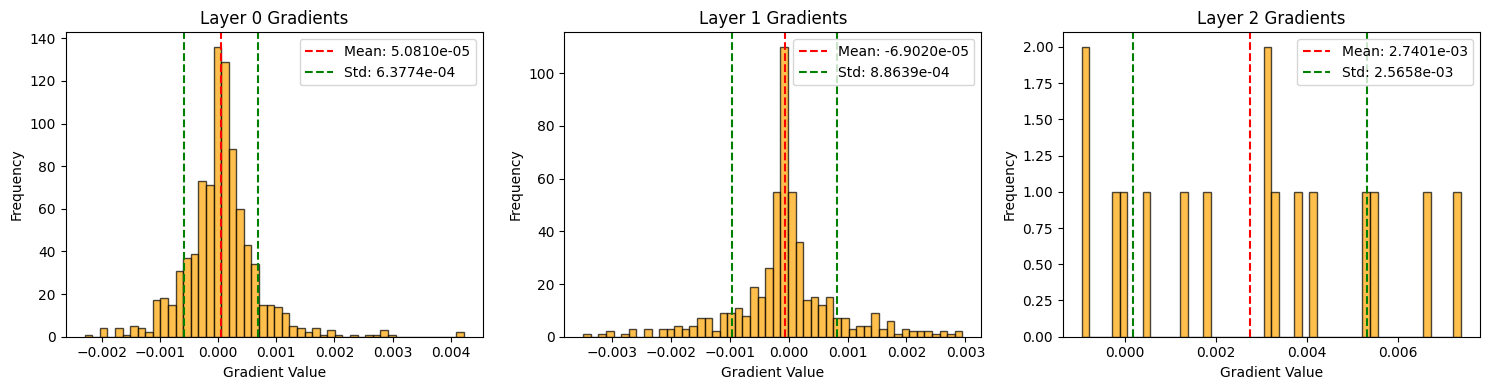


Gradient distribution for act_sigmoid


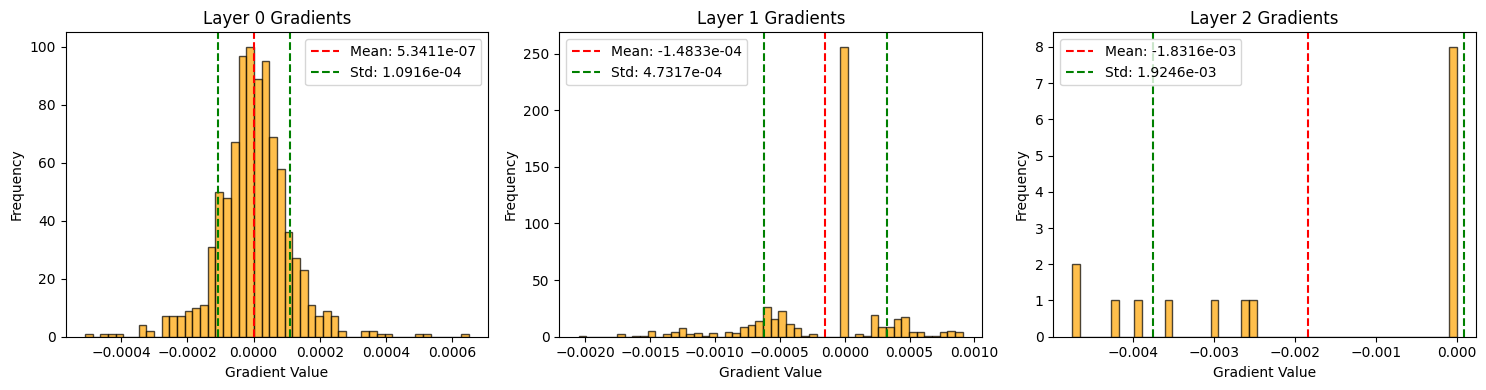


Gradient distribution for act_tanh


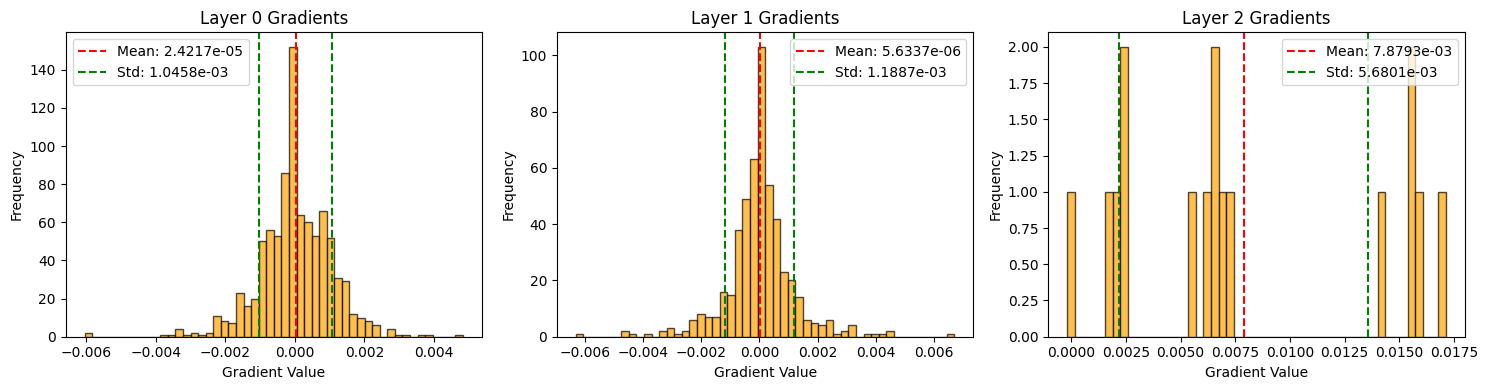

In [36]:
for r in activation_results:
    print(f"\nWeight distribution for {r['name']}")
    r["model"].plot_weight_distribution([0, 1, 2])

for r in activation_results:
    print(f"\nGradient distribution for {r['name']}")
    _ = compute_ad_gradients_once(r["model"], X_train, y_train)
    r["model"].plot_gradient_distribution([0, 1, 2])
    r["model"].network.zero_grad()

## 4.3 Variasi Learning Rate

### 4.3.1 Helper

In [37]:
lr_configs = {
    "lr_0.0001": 0.0001,
    "lr_0.001":  0.001,
    "lr_0.01":   0.01,
}

lr_results = []

for name, lr in lr_configs.items():
    result = run_ad_experiment(
        name=name,
        layer_sizes=[input_dim, 32, 16, 1],
        activations=["relu", "relu", "sigmoid"],
        optimizer=Adam(learning_rate=lr),
        initializer=Xavier(gain=1.0),
        regularizer=None,
        epochs=10,
        batch_size=32,
        learning_rate=lr,
        verbose=1
    )
    lr_results.append(result)

lr_df = summarize_results(lr_results)
lr_df

Training: 100%|██████████| 10/10 [00:00<00:00, 13.15it/s, train_loss=0.4632, val_loss=0.5251]


,model,layer_sizes,accuracy,precision,recall,f1,final_train_loss,final_val_loss
1,lr_0.001,"[28, 32, 16, 1]",0.7495,0.767988,0.849716,0.806788,0.472584,0.514485
2,lr_0.01,"[28, 32, 16, 1]",0.7430,0.756621,0.858652,0.804414,0.463155,0.525111
0,lr_0.0001,"[28, 32, 16, 1]",0.7445,0.775651,0.822908,0.798581,0.493097,0.512624


### 4.3.2 Grafik Training loss dan Validation loss

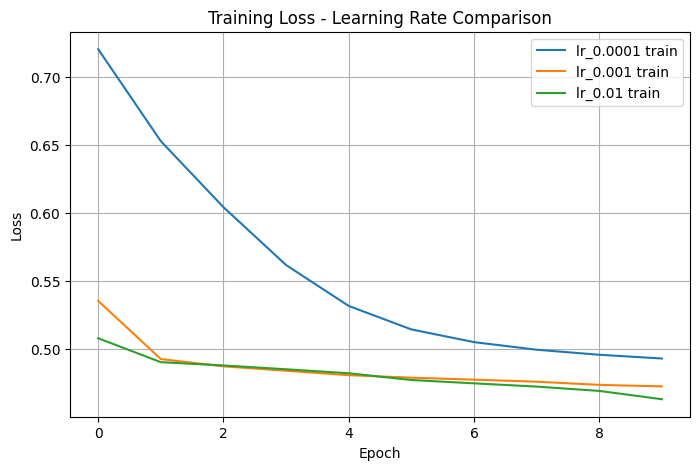

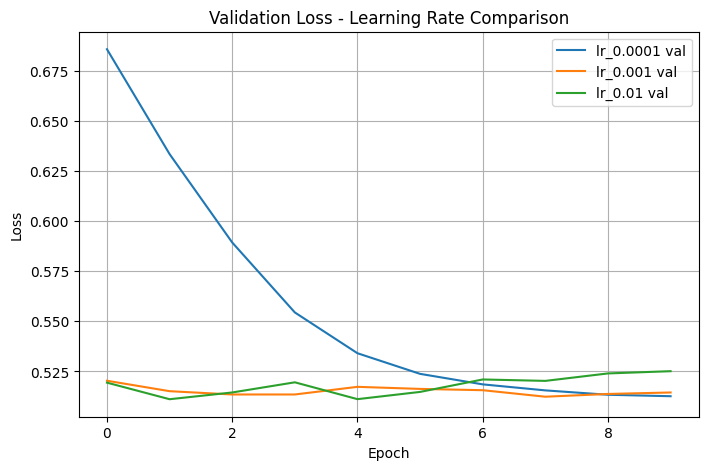

In [38]:
plot_train_loss_comparison(lr_results, "Training Loss - Learning Rate Comparison")
plot_val_loss_comparison(lr_results, "Validation Loss - Learning Rate Comparison")

### 4.3.3 Plot Distribusi bobot dan Distribusi gradien 


Weight distribution for lr_0.0001


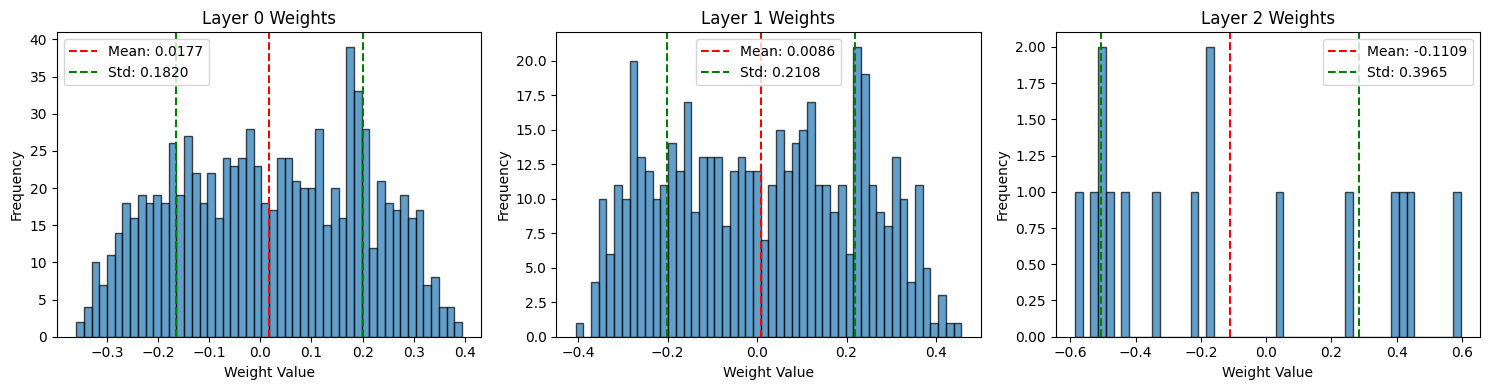


Weight distribution for lr_0.001


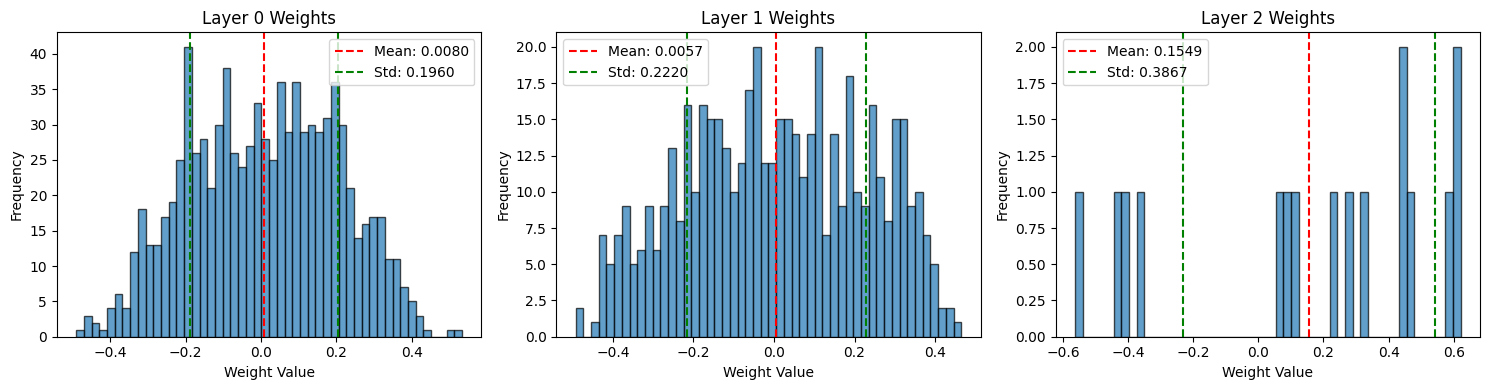


Weight distribution for lr_0.01


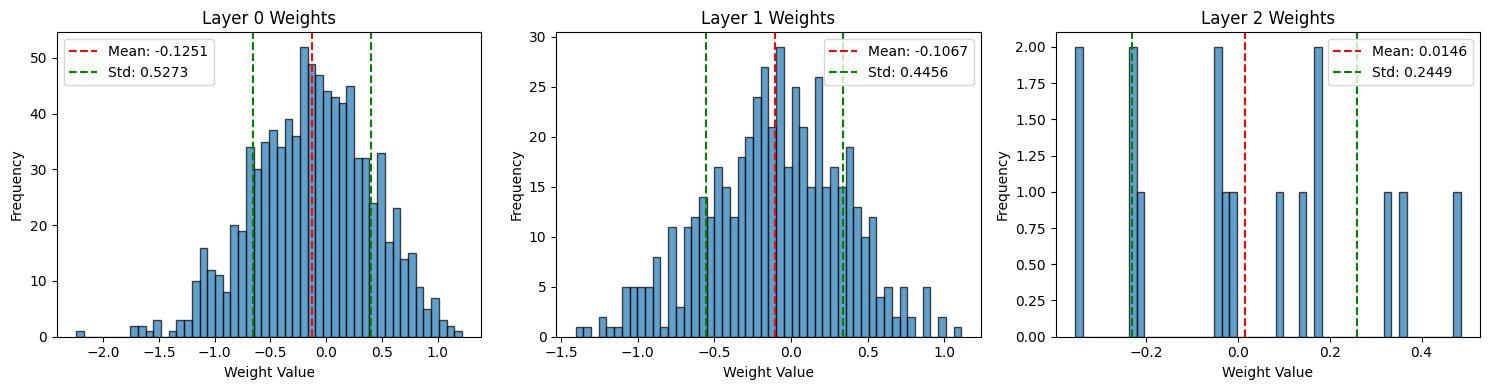


Gradient distribution for lr_0.0001


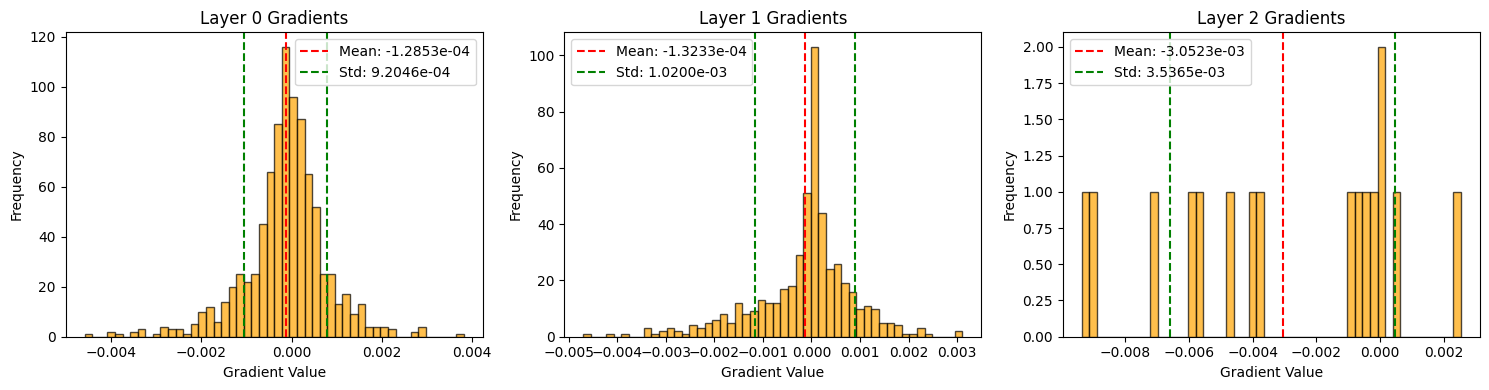


Gradient distribution for lr_0.001


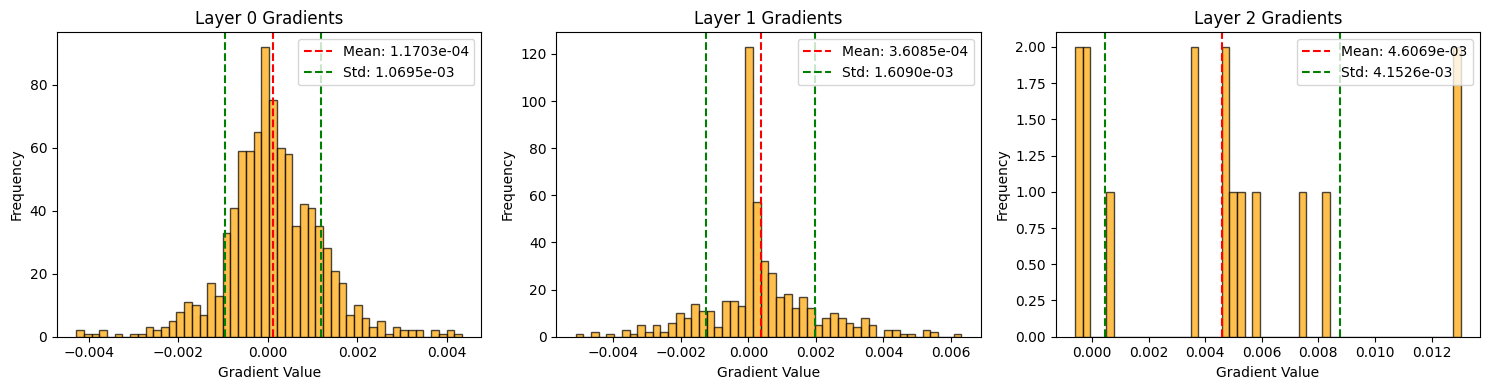


Gradient distribution for lr_0.01


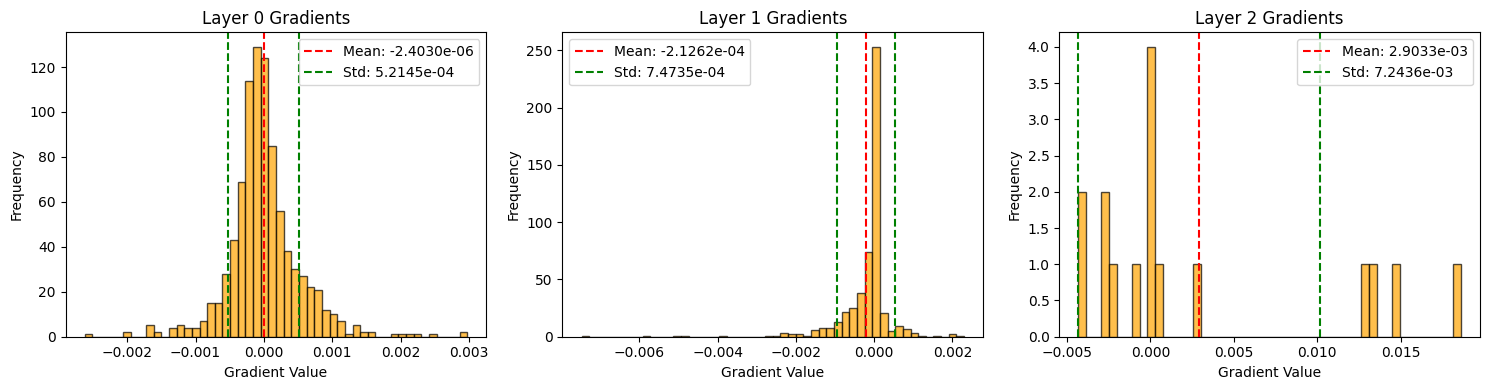

In [39]:
for r in lr_results:
    print(f"\nWeight distribution for {r['name']}")
    r["model"].plot_weight_distribution([0, 1, 2])

for r in lr_results:
    print(f"\nGradient distribution for {r['name']}")
    _ = compute_ad_gradients_once(r["model"], X_train, y_train)
    r["model"].plot_gradient_distribution([0, 1, 2])
    r["model"].network.zero_grad()

## 4.4 Pengaruh Regularisasi

### 4.4.1 Helper

In [40]:
reg_configs = {
    "no_reg": None,
    "l1": L1(lambda_=0.001),
    "l2": L2(lambda_=0.001),
}

reg_results = []

for name, reg in reg_configs.items():
    result = run_ad_experiment(
        name=name,
        layer_sizes=[input_dim, 32, 16, 1],
        activations=["relu", "relu", "sigmoid"],
        optimizer=Adam(learning_rate=0.001),
        initializer=Xavier(gain=1.0),
        regularizer=reg,
        epochs=10,
        batch_size=32,
        learning_rate=0.001,
        verbose=1
    )
    reg_results.append(result)

reg_df = summarize_results(reg_results)
reg_df

Training: 100%|██████████| 10/10 [00:00<00:00, 14.89it/s, train_loss=0.4933, val_loss=0.5071]


,model,layer_sizes,accuracy,precision,recall,f1,final_train_loss,final_val_loss
2,l2,"[28, 32, 16, 1]",0.756,0.772161,0.856214,0.812018,0.493288,0.507088
1,l1,"[28, 32, 16, 1]",0.756,0.776620,0.847279,0.810412,0.526770,0.500523
0,no_reg,"[28, 32, 16, 1]",0.749,0.773854,0.836718,0.804059,0.474201,0.515231


### 4.4.2 Grafik Training loss dan Validation loss

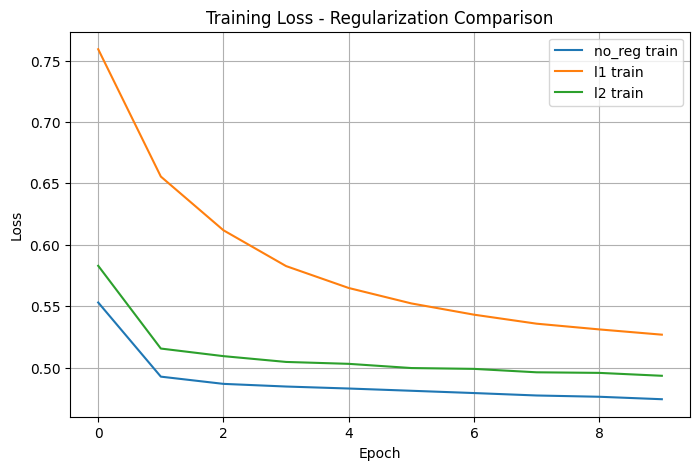

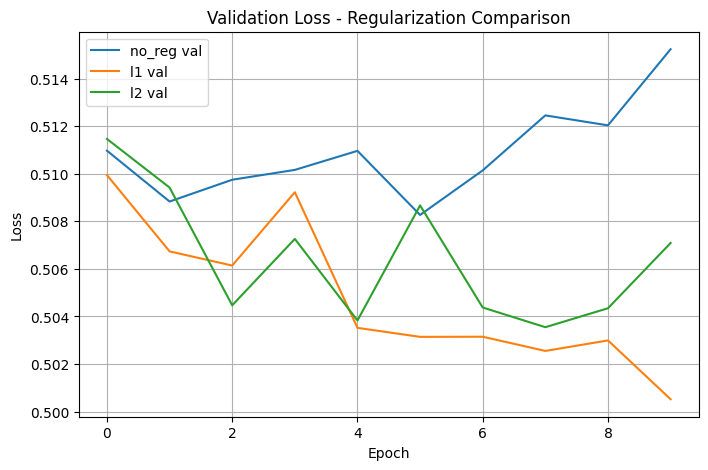

In [41]:
plot_train_loss_comparison(reg_results, "Training Loss - Regularization Comparison")
plot_val_loss_comparison(reg_results, "Validation Loss - Regularization Comparison")

### 4.4.3 Plot Distribusi bobot dan Distribusi gradien 


Weight distribution for no_reg


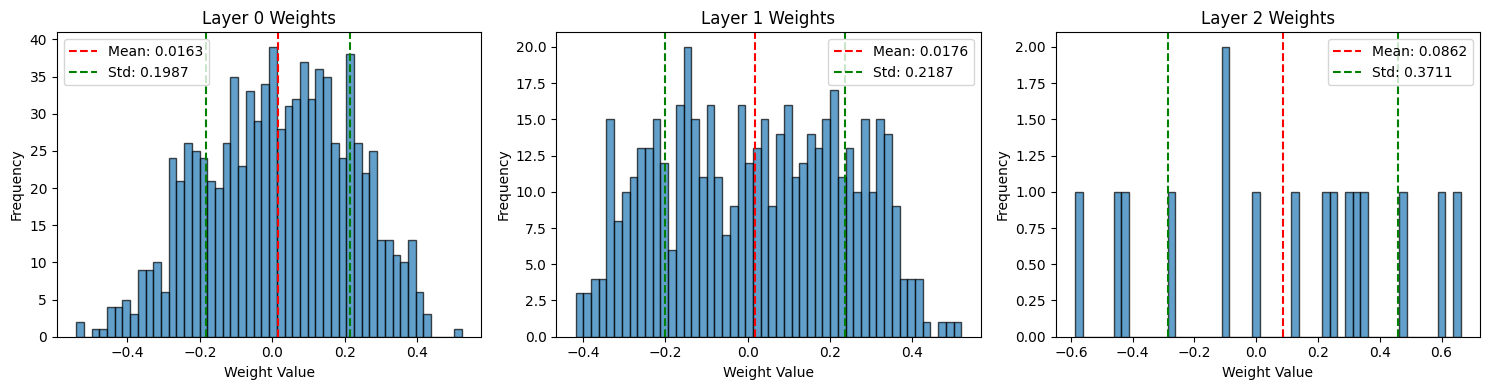


Weight distribution for l1


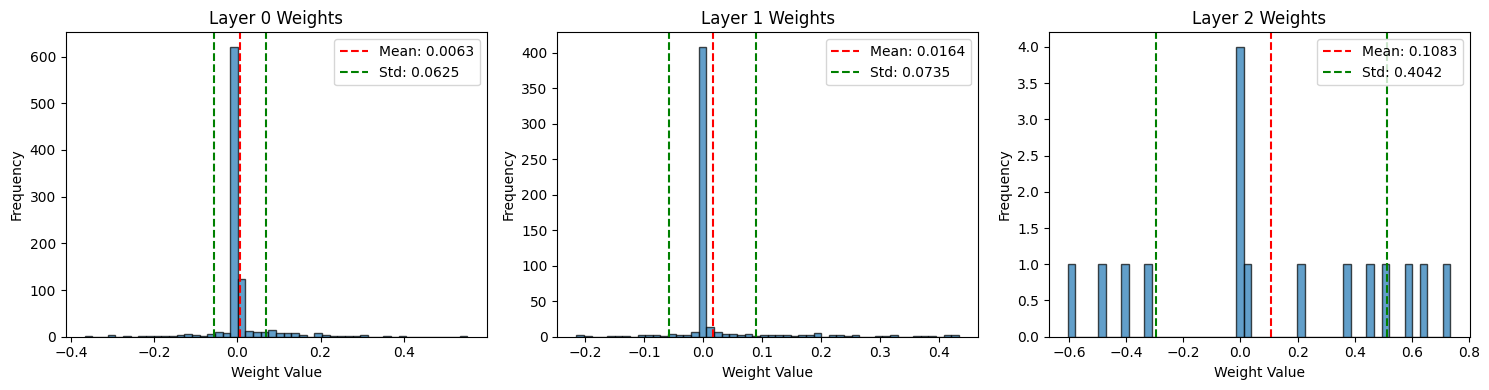


Weight distribution for l2


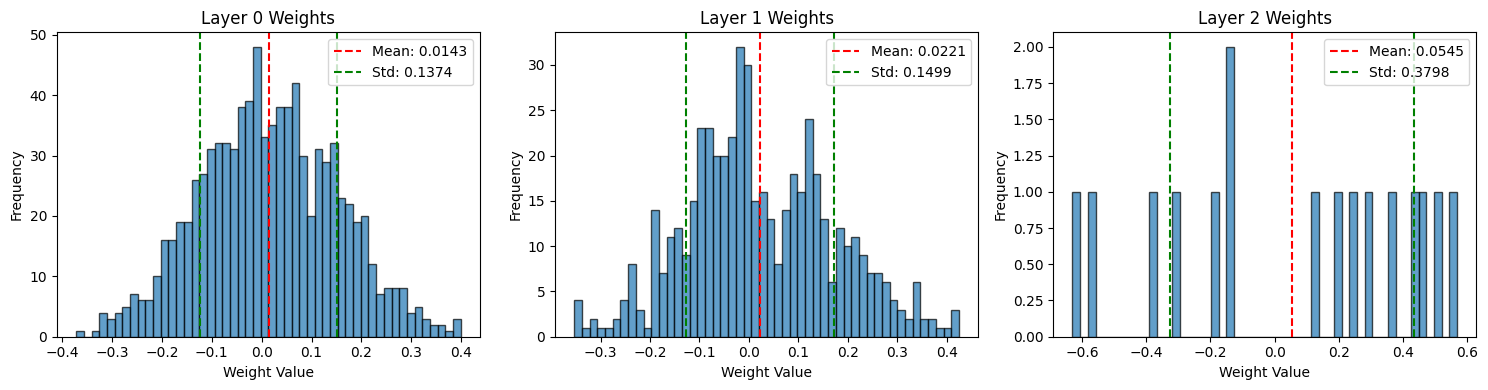


Gradient distribution for no_reg


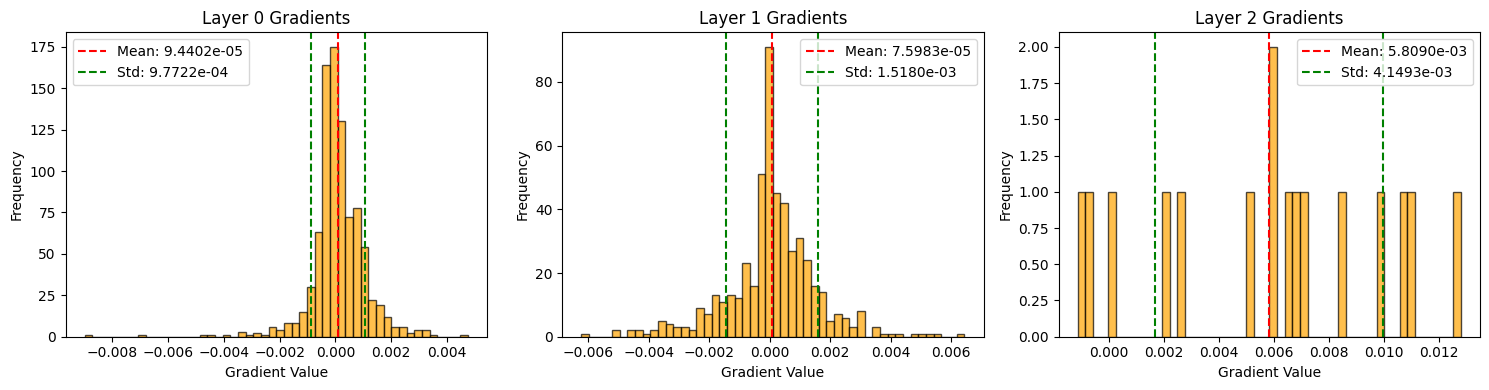


Gradient distribution for l1


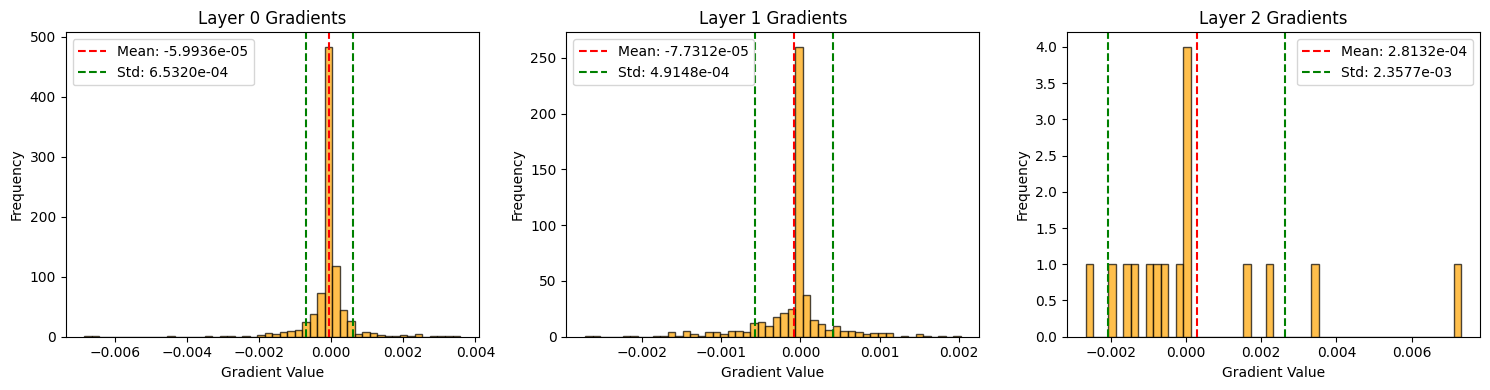


Gradient distribution for l2


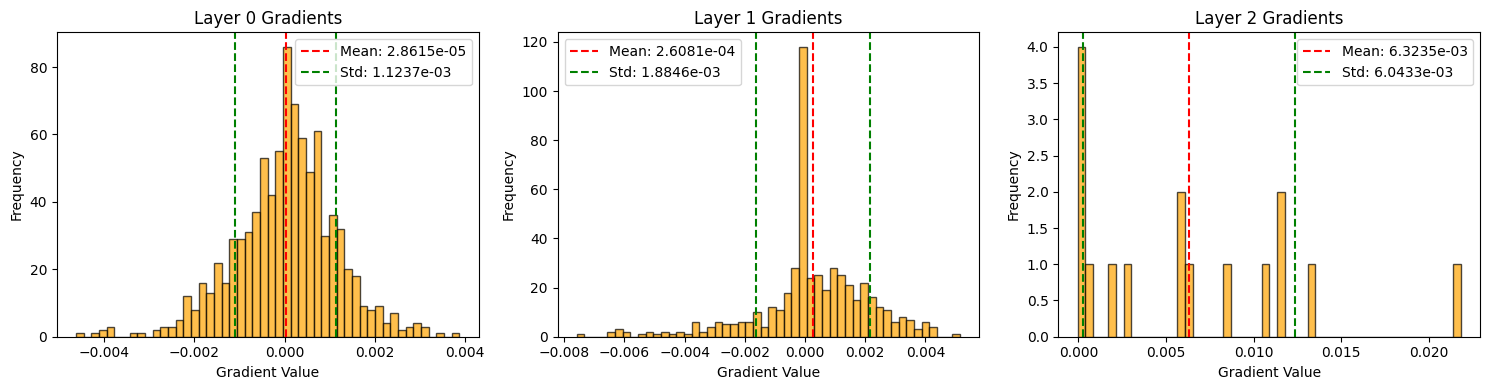

In [42]:
for r in reg_results:
    print(f"\nWeight distribution for {r['name']}")
    r["model"].plot_weight_distribution([0, 1, 2])

for r in reg_results:
    print(f"\nGradient distribution for {r['name']}")
    _ = compute_ad_gradients_once(r["model"], X_train, y_train)
    r["model"].plot_gradient_distribution([0, 1, 2])
    r["model"].network.zero_grad()

## 4.5 Uji Perbandingan RMSNorm

In [43]:
np.random.seed(RANDOM_STATE)

rmsnorm_config = {
    "layer_sizes": [input_dim, 16, 8, 1],
    "activations": ["relu", "relu", "sigmoid"],
    "loss": "bce",
    "initializer": Xavier(gain=1.0),
    "regularizer": L2(lambda_=0.001),
    "epochs": 10,
    "batch_size": 32,
    "learning_rate": 0.001,
    "verbose": 1,
}

### 4.5.1 No RMSNorm

In [44]:
model_no_norm = ADModel(
    layer_sizes=rmsnorm_config["layer_sizes"],
    activations=rmsnorm_config["activations"],
    loss=rmsnorm_config["loss"],
    optimizer=Adam(learning_rate=rmsnorm_config["learning_rate"]),
    initializer=rmsnorm_config["initializer"],
    regularizer=rmsnorm_config["regularizer"],
    use_rmsnorm=False,
)

history_no_norm = model_no_norm.fit(
    X_train, y_train,
    X_val, y_val,
    epochs=rmsnorm_config["epochs"],
    batch_size=rmsnorm_config["batch_size"],
    verbose=rmsnorm_config["verbose"],
    learning_rate=rmsnorm_config["learning_rate"],
)

Training: 100%|██████████| 10/10 [00:00<00:00, 13.62it/s, train_loss=0.4942, val_loss=0.5066]


### 4.5.2 RMSNorm

In [45]:
model_rmsnorm = ADModel(
    layer_sizes=rmsnorm_config["layer_sizes"],
    activations=rmsnorm_config["activations"],
    loss=rmsnorm_config["loss"],
    optimizer=Adam(learning_rate=rmsnorm_config["learning_rate"]),
    initializer=rmsnorm_config["initializer"],
    regularizer=rmsnorm_config["regularizer"],
    use_rmsnorm=True,
    rmsnorm_eps=1e-8,
)

history_rmsnorm = model_rmsnorm.fit(
    X_train, y_train,
    X_val, y_val,
    epochs=rmsnorm_config["epochs"],
    batch_size=rmsnorm_config["batch_size"],
    verbose=rmsnorm_config["verbose"],
    learning_rate=rmsnorm_config["learning_rate"],
)

Training: 100%|██████████| 10/10 [00:01<00:00,  9.73it/s, train_loss=0.4959, val_loss=0.5237]


In [46]:
print(model_no_norm)
print(model_rmsnorm)

print("No RMSNorm param tensors:", len(model_no_norm.network.parameters()))
print("With RMSNorm param tensors:", len(model_rmsnorm.network.parameters()))

for i, layer in enumerate(model_rmsnorm.network.layers):
    print(i, layer)

ADModel(loss='bce', use_rmsnorm=False, network=ADNetwork(
  (0): ADLayer(in=28, out=16, activation='relu', rmsnorm=False)
  (1): ADLayer(in=16, out=8, activation='relu', rmsnorm=False)
  (2): ADLayer(in=8, out=1, activation='sigmoid', rmsnorm=False)
))
ADModel(loss='bce', use_rmsnorm=True, network=ADNetwork(
  (0): ADLayer(in=28, out=16, activation='relu', rmsnorm=True)
  (1): ADLayer(in=16, out=8, activation='relu', rmsnorm=True)
  (2): ADLayer(in=8, out=1, activation='sigmoid', rmsnorm=False)
))
No RMSNorm param tensors: 6
With RMSNorm param tensors: 8
0 ADLayer(in=28, out=16, activation='relu', rmsnorm=True)
1 ADLayer(in=16, out=8, activation='relu', rmsnorm=True)
2 ADLayer(in=8, out=1, activation='sigmoid', rmsnorm=False)


In [47]:
def evaluate_binary_model(model, X, y):
    y_prob = model.predict(X)
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred, zero_division=0),
    }

metrics_no_norm = evaluate_binary_model(model_no_norm, X_val, y_val)
metrics_rmsnorm = evaluate_binary_model(model_rmsnorm, X_val, y_val)

results_rmsnorm = pd.DataFrame([
    {"model": "No RMSNorm", **metrics_no_norm,
     "final_train_loss": history_no_norm["train_loss"][-1],
     "final_val_loss": history_no_norm["val_loss"][-1]},
    {"model": "With RMSNorm", **metrics_rmsnorm,
     "final_train_loss": history_rmsnorm["train_loss"][-1],
     "final_val_loss": history_rmsnorm["val_loss"][-1]},
])

results_rmsnorm

,model,accuracy,precision,recall,f1,final_train_loss,final_val_loss
0,No RMSNorm,0.7485,0.783931,0.816409,0.799841,0.494188,0.506608
1,With RMSNorm,0.7505,0.765602,0.857027,0.808739,0.495861,0.523729


### 4.5.3 Grafik Training loss dan Validation loss

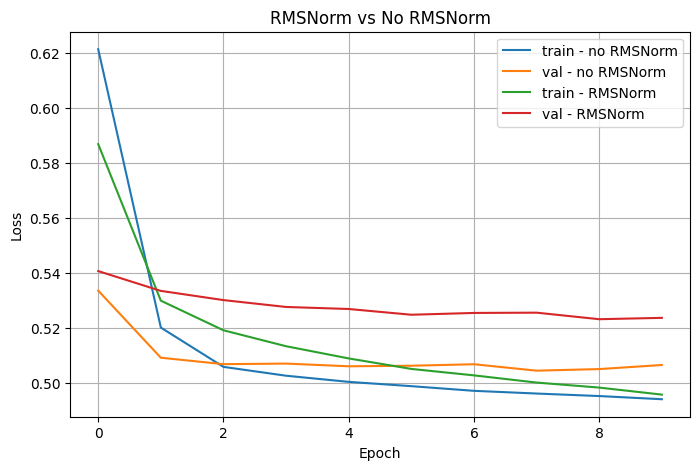

In [48]:
plt.figure(figsize=(8, 5))
plt.plot(history_no_norm["train_loss"], label="train - no RMSNorm")
plt.plot(history_no_norm["val_loss"], label="val - no RMSNorm")
plt.plot(history_rmsnorm["train_loss"], label="train - RMSNorm")
plt.plot(history_rmsnorm["val_loss"], label="val - RMSNorm")
plt.title("RMSNorm vs No RMSNorm")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### 4.5.4 Plot Distribusi bobot dan Distribusi gradien 

Weight distribution - No RMSNorm


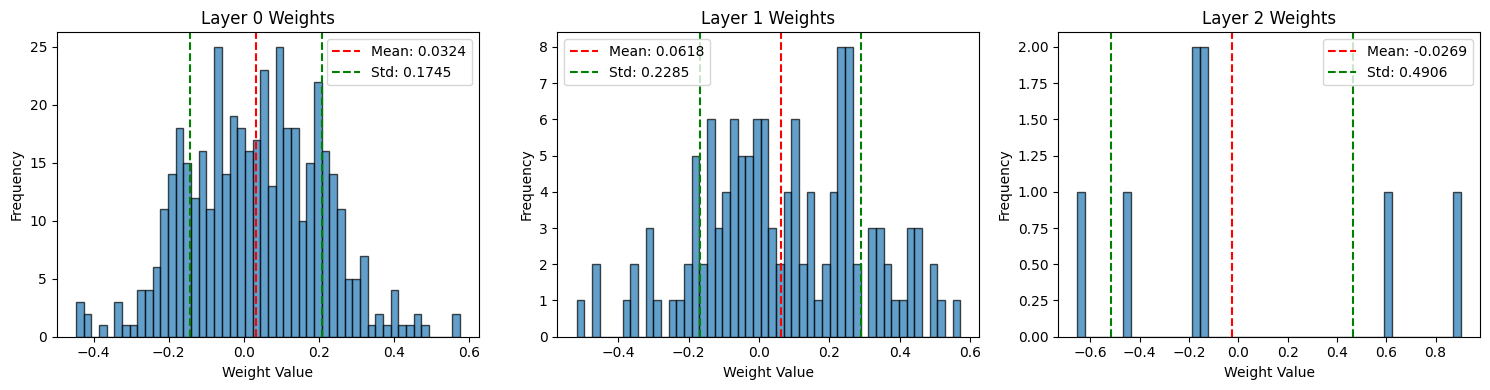

Weight distribution - With RMSNorm


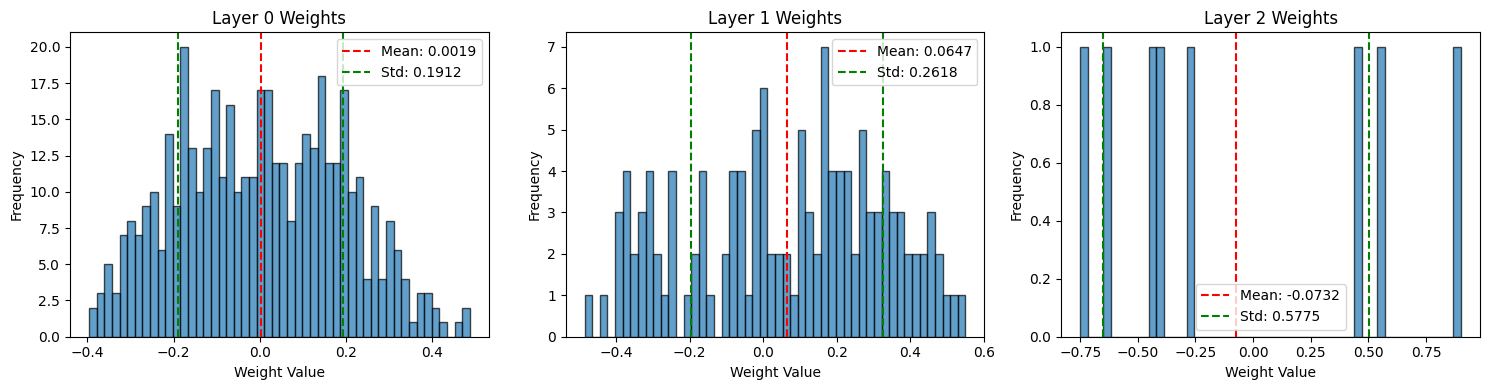

In [49]:
print("Weight distribution - No RMSNorm")
model_no_norm.plot_weight_distribution([0, 1, 2])

print("Weight distribution - With RMSNorm")
model_rmsnorm.plot_weight_distribution([0, 1, 2])

In [50]:
def capture_probe_gradients(model, X_probe, y_probe):
    model.network.zero_grad()

    x_t = Tensor.from_numpy(X_probe)
    y_t = Tensor.from_numpy(y_probe)

    pred = model.network.forward(x_t)
    loss_t = model._loss_fn(pred, y_t)
    loss_t.backward()

    if model.regularizer is not None:
        for layer in model.network.layers:
            reg_grad = model.regularizer.gradient(layer.weights.data)
            if layer.weights.grad is not None:
                layer.weights.grad += reg_grad
            else:
                layer.weights.grad = reg_grad

    return float(loss_t.data)

In [51]:
X_probe = X_train[:64]
y_probe = y_train[:64]

probe_loss_no = capture_probe_gradients(model_no_norm, X_probe, y_probe)
probe_loss_rms = capture_probe_gradients(model_rmsnorm, X_probe, y_probe)

print("Probe loss no RMSNorm:", probe_loss_no)
print("Probe loss with RMSNorm:", probe_loss_rms)

Probe loss no RMSNorm: 0.4778004777645117
Probe loss with RMSNorm: 0.4531879154220707


Gradient distribution - No RMSNorm


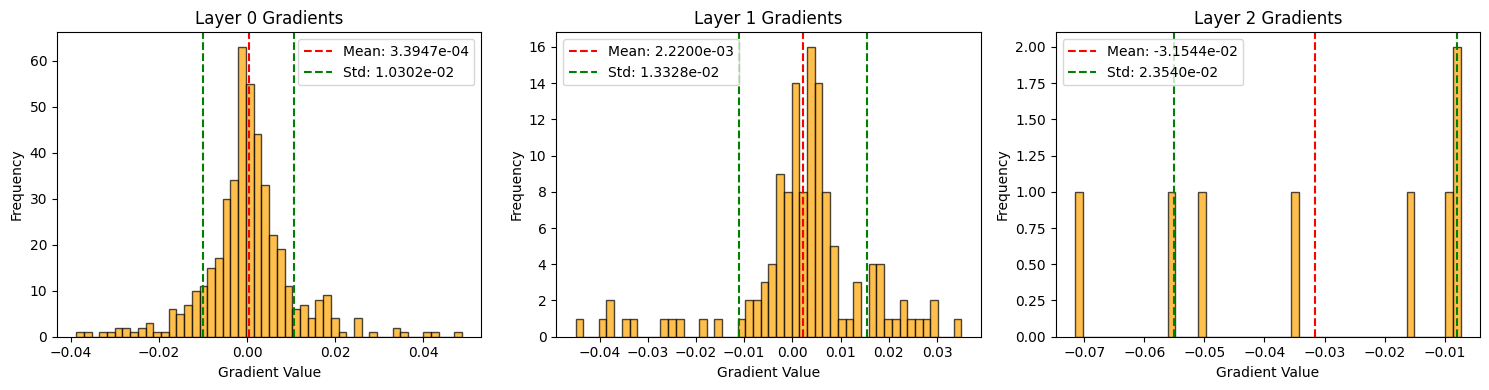

Gradient distribution - With RMSNorm


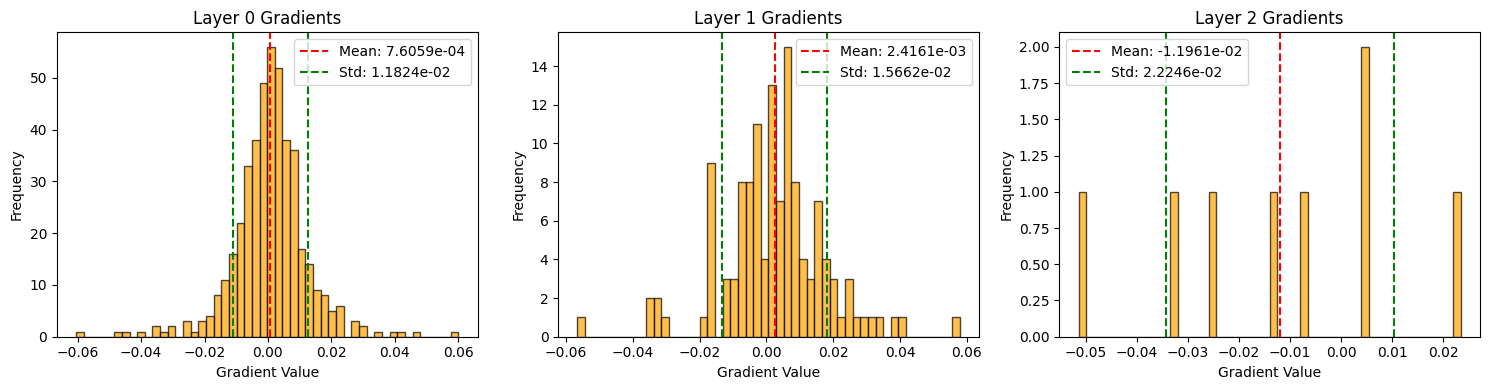

In [52]:
print("Gradient distribution - No RMSNorm")
model_no_norm.plot_gradient_distribution([0, 1, 2])

print("Gradient distribution - With RMSNorm")
model_rmsnorm.plot_gradient_distribution([0, 1, 2])

## 4.6 Uji Perbandingan

In [53]:

RANDOM_STATE = 42

compare_config = {
    "layer_sizes": [input_dim, 16, 8, 1],
    "hidden_sizes_sklearn": (16, 8),
    "activations": ["relu", "relu", "sigmoid"],   # scratch
    "sklearn_activation": "relu",                 # sklearn hidden activation
    "loss": "bce",
    "learning_rate": 0.001,
    "batch_size": 32,
    "epochs": 10,
    "l2_lambda": 0.001,
}

### 4.6.1 SKLearn

In [54]:
sk_model = MLPClassifier(
    hidden_layer_sizes=compare_config["hidden_sizes_sklearn"],
    activation=compare_config["sklearn_activation"],
    solver="adam",
    alpha=compare_config["l2_lambda"],          # L2 regularization
    batch_size=compare_config["batch_size"],
    learning_rate="constant",
    learning_rate_init=compare_config["learning_rate"],
    max_iter=compare_config["epochs"],
    shuffle=True,
    random_state=RANDOM_STATE,
    early_stopping=False,
    verbose=False
)

sk_model.fit(X_train, y_train.ravel())

sk_pred = sk_model.predict(X_val).reshape(-1)
sk_prob = sk_model.predict_proba(X_val)[:, 1]

### 4.6.2 Scratch

In [55]:
scratch_model = ADModel(
    layer_sizes=compare_config["layer_sizes"],
    activations=compare_config["activations"],
    loss=compare_config["loss"],
    optimizer=Adam(learning_rate=compare_config["learning_rate"]),
    initializer=Xavier(gain=1.0),
    regularizer=L2(lambda_=compare_config["l2_lambda"]),
)

scratch_history = scratch_model.fit(
    X_train, y_train,
    X_val, y_val,
    epochs=compare_config["epochs"],
    batch_size=compare_config["batch_size"],
    verbose=1,
    learning_rate=compare_config["learning_rate"],
)

scratch_prob = scratch_model.predict(X_val)
scratch_pred = (scratch_prob >= 0.5).astype(int).reshape(-1)
y_true = y_val.reshape(-1)

Training: 100%|██████████| 10/10 [00:00<00:00, 15.74it/s, train_loss=0.5046, val_loss=0.5170]


### 4.6.3 Perbandingan

In [56]:
comparison_df = pd.DataFrame({
    "model": ["scratch", "sklearn"],
    "accuracy": [
        accuracy_score(y_true, scratch_pred),
        accuracy_score(y_true, sk_pred)
    ],
    "precision": [
        precision_score(y_true, scratch_pred, zero_division=0),
        precision_score(y_true, sk_pred, zero_division=0)
    ],
    "recall": [
        recall_score(y_true, scratch_pred, zero_division=0),
        recall_score(y_true, sk_pred, zero_division=0)
    ],
    "f1": [
        f1_score(y_true, scratch_pred, zero_division=0),
        f1_score(y_true, sk_pred, zero_division=0)
    ]
})

comparison_df

,model,accuracy,precision,recall,f1
0,scratch,0.7495,0.790605,0.806661,0.798552
1,sklearn,0.7540,0.775952,0.844029,0.808560
